## Experiment Overview: Learning the Score Function of a VP OU Process

### 1. The Variance Preserving (VP) OU Process
We model our system using a Variance Preserving (VP) Ornstein-Uhlenbeck (OU) process. The dynamics of this process are governed by the following Stochastic Differential Equation (SDE):

$$ dX_t = -\frac{1}{2} \beta(t) X_t dt + \sqrt{\beta(t)} dW_t $$

where $W_t$ is a standard Wiener process and $\beta(t)$ is the noise schedule. In a **constant temperature** setting, $\beta(t) = \beta > 0$ is completely constant. 

This process is uniquely powerful for generative modeling because it is "variance preserving": as $t \to \infty$, the distribution smoothly converges to a standard normal distribution $\mathcal{N}(0, 1)$, regardless of the data distribution at $t=0$.

### 2. Sampling from the Process
Because the drift coefficient is linear and the diffusion coefficient depends only on time, the transition kernel $q(X_t | X_0)$ is perfectly tractable and Gaussian. This allows us to sample the state $X_t$ at any arbitrary time $t$ without needing step-by-step numerical integration (like Euler-Maruyama). 

The analytical transition probability is:

$$ q(X_t | X_0) = \mathcal{N}\left(X_t; \mu_t, \sigma_t^2 \right) $$

where for a constant $\beta$:
*   **Mean:** $\mu_t = X_0 e^{-\frac{1}{2} \beta t}$
*   **Variance:** $\sigma_t^2 = 1 - e^{-\beta t}$

To sample a state point, we use the reparameterization trick with standard Gaussian noise $\epsilon \sim \mathcal{N}(0, 1)$:

$$ X_t = X_0 e^{-\frac{1}{2} \beta t} + \sqrt{1 - e^{-\beta t}} \epsilon $$

### 3. Training the Neural Network
The neural network $s_\theta(x, t)$ acts as a score-based model. Its goal is to approximate the true, often intractable, marginal score $\nabla_x \log p_t(x)$. 

To bypass the need to know the marginal distribution $p_t(x)$, we train the network using **Denoising Score Matching (DSM)**. This uses the tractable conditional score $\nabla_{X_t} \log q(X_t | X_0)$.

For our Gaussian perturbation kernel, the exact conditional score is easily computed as:

$$ \nabla_{X_t} \log q(X_t | X_0) = -\frac{X_t - \mu_t}{\sigma_t^2} $$

We iteratively train the network by drawing batches of $(X_0, t, \epsilon)$ to minimize the expected score-matching objective:

$$ \mathcal{L}(\theta) = \mathbb{E}_{t \sim \mathcal{U}(0, T), X_0 \sim p_0, \epsilon \sim \mathcal{N}(0, I)} \left[ \lambda(t) \left\| s_\theta(X_t, t) - \left(-\frac{\epsilon}{\sigma_t}\right) \right\|_2^2 \right] $$

Once trained, $s_\theta(x, t) \approx \nabla_x \log p_t(x)$. We can then visually compare the network's approximation against analytical derivations across varying starting distributions.
## Bimodal Gaussian Distribution

### Starting Distribution
The initial distribution is a mixture of two Gaussians (GMM) with equal weights:
$$ p_0(x) = \frac{1}{2}\mathcal{N}(x; \mu_1, \sigma_1^2) + \frac{1}{2}\mathcal{N}(x; \mu_2, \sigma_2^2) $$

### Marginal Distribution at Time $t$
For a VP OU process with constant $\beta$, the transition kernel is $q(X_t | X_0) = \mathcal{N}(X_t; X_0 \alpha_t, v_t)$ where $\alpha_t = e^{-\frac{1}{2}\beta t}$ and $v_t = 1 - e^{-\beta t}$. 
The marginal distribution $p_t(x)$ remains a Gaussian mixture:
$$ p_t(x) = \frac{1}{2}\mathcal{N}(x; m_{1}(t), S_{1}(t)) + \frac{1}{2}\mathcal{N}(x; m_{2}(t), S_{2}(t)) $$
where $m_{i}(t) = \alpha_t \mu_i$ and $S_{i}(t) = \alpha_t^2 \sigma_i^2 + v_t$ for $i \in \{1, 2\}$.

### Analytical Score Function
The exact analytical score function $\nabla_x \log p_t(x)$ is given by the weighted sum of the individual component scores:
$$ \nabla_x \log p_t(x) = \frac{ p_{t,1}(x) \left(-\frac{x - m_1(t)}{S_1(t)}\right) + p_{t,2}(x) \left(-\frac{x - m_2(t)}{S_2(t)}\right) }{ p_{t,1}(x) + p_{t,2}(x) } $$
where $p_{t,i}(x) = \mathcal{N}(x; m_i(t), S_i(t))$.

In [39]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Parameters
beta = 1.0
T = 1.0
mu_1, sigma_1 = -2.0, 0.5
mu_2, sigma_2 = 2.0, 0.5
batch_size = 1000
iterations = 6000
lr = 1e-3

# Score Network Architecture
class ScoreNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 12),
            nn.ReLU(),
            nn.Linear(12, 12),
            nn.ReLU(),
            nn.Linear(12, 1)
        )
    
    def forward(self, x, t):
        # Concatenate x and t
        xt = torch.cat([x, t], dim=-1)
        return self.net(xt)

# Sampling from Bimodal Gaussian
def sample_p0(batch_size):
    modes = torch.randint(0, 2, (batch_size, 1)).float()
    noise = torch.randn(batch_size, 1)
    
    samples_1 = mu_1 + sigma_1 * noise
    samples_2 = mu_2 + sigma_2 * noise
    return (1 - modes) * samples_1 + modes * samples_2

# Training setup
model = ScoreNet()
optimizer = optim.Adam(model.parameters(), lr=lr)

# Training Loop
model.train()
for i in range(iterations):
    optimizer.zero_grad()
    
    x_0 = sample_p0(batch_size)
    t = torch.rand(batch_size, 1) * T
    epsilon = torch.randn_like(x_0)
    
    # VP OU parameters
    alpha_t = torch.exp(-0.5 * beta * t)
    var_t = 1 - torch.exp(-beta * t)
    std_t = torch.sqrt(var_t)
    
    # Perturb data
    x_t = alpha_t * x_0 + std_t * epsilon
    
    # Predict score and loss (DSM)
    predicted_score = model(x_t, t)
    target_score = -epsilon / std_t
    
    # Optional lambda(t) weighting could be added, here we use standard MSE
    loss = torch.mean((predicted_score - target_score) ** 2)
    
    loss.backward()
    optimizer.step()
    
    if (i + 1) % 1000 == 0:
        print(f"Iteration {i+1}/{iterations} | Loss: {loss.item():.4f}")

Iteration 1000/6000 | Loss: 85.4183
Iteration 2000/6000 | Loss: 6.5255
Iteration 3000/6000 | Loss: 4.2077
Iteration 4000/6000 | Loss: 17.6599
Iteration 5000/6000 | Loss: 5.0385
Iteration 6000/6000 | Loss: 8.7102


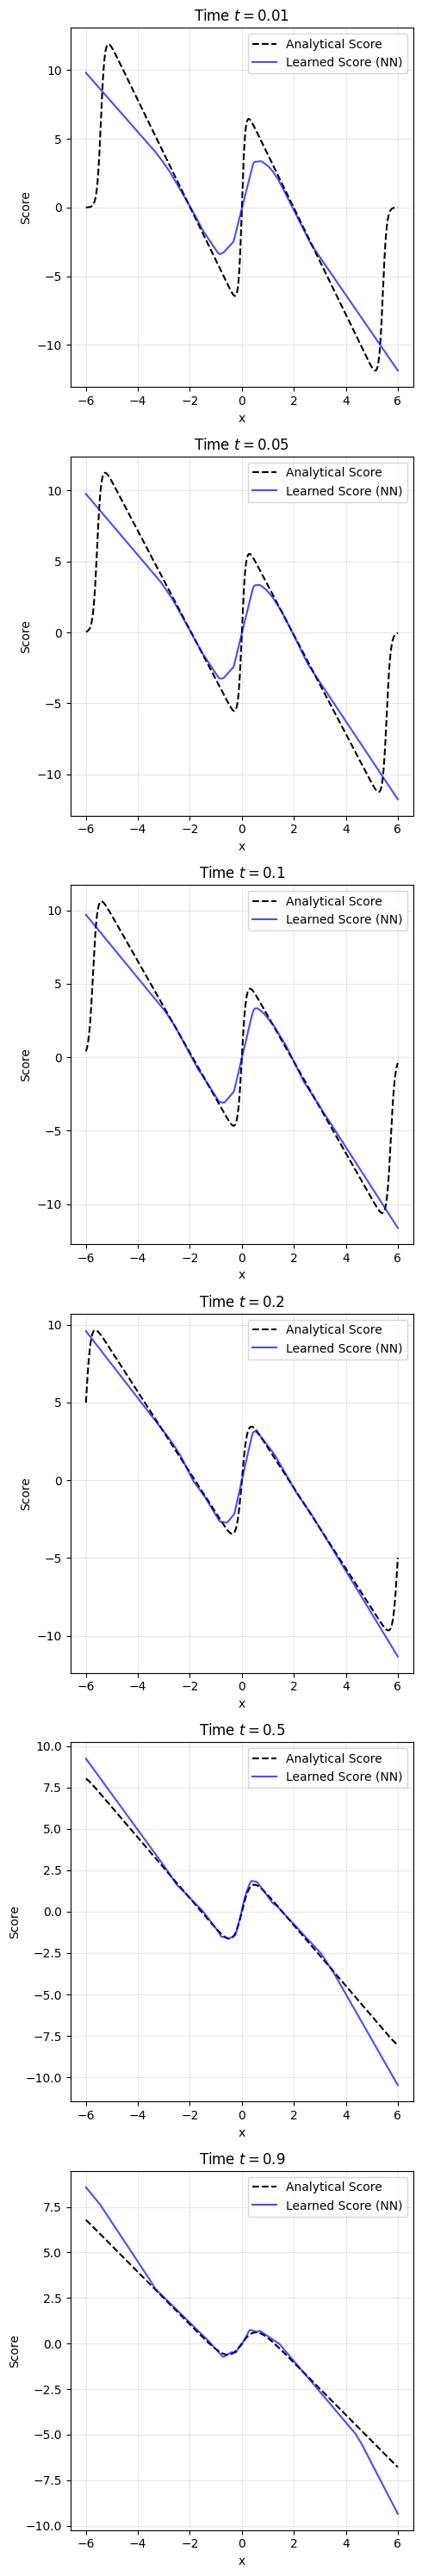

In [40]:
import math

def analytical_score(x, t):
    alpha_t = math.exp(-0.5 * beta * t)
    v_t = 1.0 - math.exp(-beta * t)
    
    m1_t = alpha_t * mu_1
    S1_t = (alpha_t**2) * (sigma_1**2) + v_t
    
    m2_t = alpha_t * mu_2
    S2_t = (alpha_t**2) * (sigma_2**2) + v_t
    
    # Calculate PDFs safely
    def gaussian_pdf(val, mean, var):
        return torch.exp(-0.5 * ((val - mean)**2) / var) / math.sqrt(2 * math.pi * var)
    
    p1 = gaussian_pdf(x, m1_t, S1_t)
    p2 = gaussian_pdf(x, m2_t, S2_t)
    
    score1 = -(x - m1_t) / S1_t
    score2 = -(x - m2_t) / S2_t
    
    # Weighted sum
    score = (p1 * score1 + p2 * score2) / (p1 + p2 + 1e-10)
    return score

# Visual Comparison
model.eval()
evaluate_times = [0.01,0.05, 0.1, 0.2, 0.5, 0.9]
n_times = len(evaluate_times)
x_vals = torch.linspace(-6, 6, 400).unsqueeze(1)

fig, axes = plt.subplots(n_times, 1, figsize=(5, 5* n_times))
axes = axes.flatten()

with torch.no_grad():
    for idx, t_val in enumerate(evaluate_times):
        t_tensor = torch.full_like(x_vals, t_val)
        
        # Neural Network Score
        nn_score = model(x_vals, t_tensor).squeeze(-1)
        
        # Analytical Score
        true_score = analytical_score(x_vals, t_val).squeeze(-1)
        
        ax = axes[idx]
        ax.plot(x_vals.numpy(), true_score.numpy(), label="Analytical Score", color="black", linestyle="--")
        ax.plot(x_vals.numpy(), nn_score.numpy(), label="Learned Score (NN)", color="blue", alpha=0.7)
        
        ax.set_title(f"Time $t = {t_val}$")
        ax.set_xlabel("x")
        ax.set_ylabel("Score")
        #ax.set_ylim(-5, 5)
        ax.legend()
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

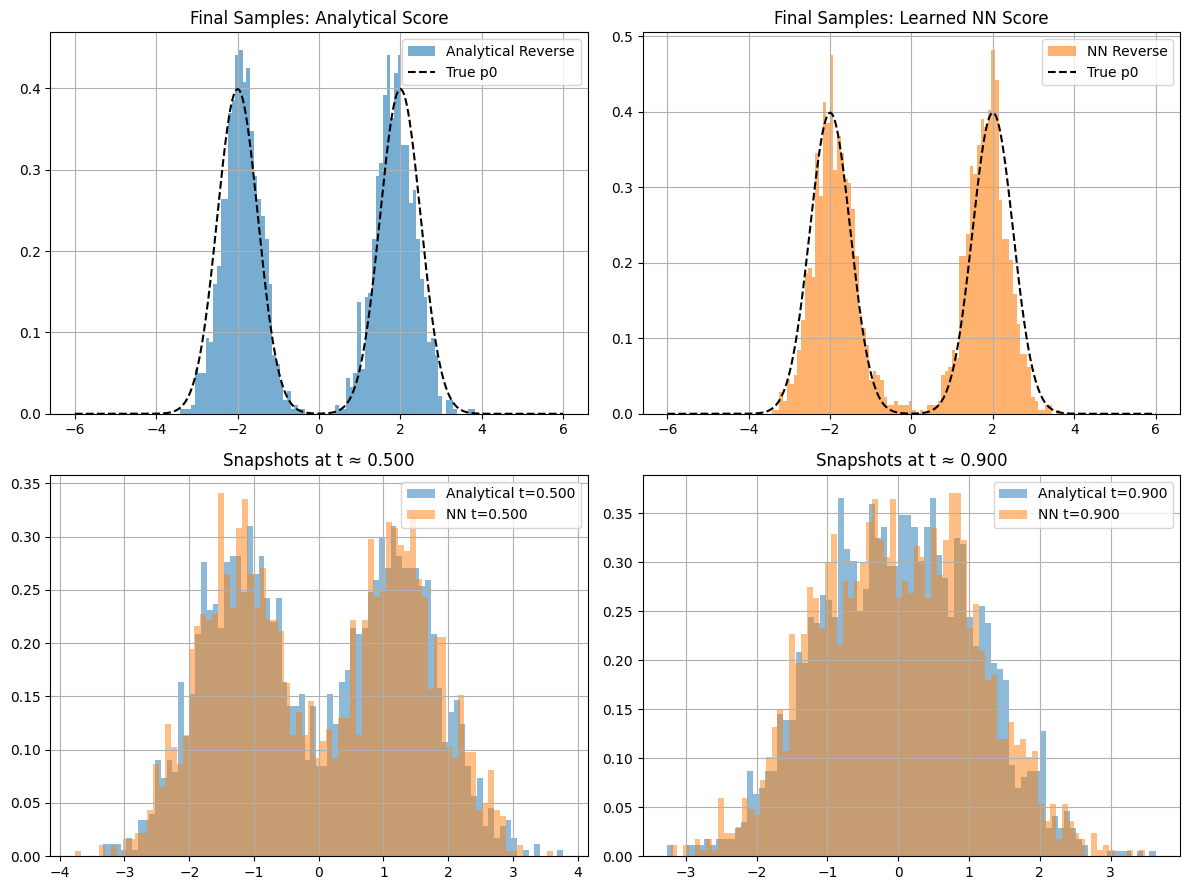

In [41]:
# Reverse-time sampling (compare analytical vs learned score)
import torch
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device).eval()

# Convert constants to torch on device
mu1_t = torch.tensor(mu_1, dtype=torch.float32, device=device)
mu2_t = torch.tensor(mu_2, dtype=torch.float32, device=device)
sig1_sq = float(sigma_1**2)
sig2_sq = float(sigma_2**2)
beta_t = float(beta)

def analytical_score_tensor(x, t):
    # x: (N,1) tensor; t: scalar float
    t_t = torch.tensor(t, dtype=torch.float32, device=device)
    alpha = torch.exp(-0.5 * beta_t * t_t)
    v = 1.0 - torch.exp(-beta_t * t_t)
    m1 = alpha * mu1_t
    m2 = alpha * mu2_t
    S1 = (alpha**2) * sig1_sq + v
    S2 = (alpha**2) * sig2_sq + v
    # pdfs
    norm1 = torch.exp(-0.5 * ((x - m1)**2) / S1) / torch.sqrt(2 * torch.pi * S1)
    norm2 = torch.exp(-0.5 * ((x - m2)**2) / S2) / torch.sqrt(2 * torch.pi * S2)
    s1 = -(x - m1) / S1
    s2 = -(x - m2) / S2
    return (norm1 * s1 + norm2 * s2) / (norm1 + norm2 + 1e-12)

def nn_score_tensor(x, t):
    # x: (N,1), t: scalar float -> returns (N,1)
    t_tensor = torch.full_like(x, float(t), device=device)
    return model(x, t_tensor)

def reverse_sampler(score_fn, n_samples=1000, n_steps=500):
    # time grid descending from T to 0
    times = np.linspace(T, 0.0, n_steps + 1)  # descending
    x = torch.randn(n_samples, 1, device=device)  # start ~ N(0,1) at t=T
    traj_snapshots = {}  # store snapshots for selected times
    snapshot_times = [0.9 * T, 0.5 * T, 0.2 * T, 0.0]
    for i in range(n_steps):
        t_cur = float(times[i])
        t_next = float(times[i + 1])
        dt = t_next - t_cur  # negative
        x_det = -0.5 * beta_t * x  # f(x,t)
        with torch.no_grad():
            score = score_fn(x, t_cur)
        rev_drift = x_det - (beta_t * score)  # f - g^2 * score (g^2 = beta)
        # update: x_{t_next} = x_{t_cur} + rev_drift * dt + g * sqrt(|dt|) * z
        noise = torch.randn_like(x, device=device)
        x = x + rev_drift * dt + torch.sqrt(torch.tensor(beta_t * abs(dt), device=device)) * noise
        # save snapshot if close to requested times
        for st in snapshot_times:
            if abs(t_next - st) < (T / n_steps) * 0.51:
                traj_snapshots[round(st, 5)] = x.clone().cpu()
    return x.cpu(), traj_snapshots

# Run both samplers
n_samples = 2000
n_steps = 1000

# Analytical reverse
final_analytical, snaps_analytical = reverse_sampler(analytical_score_tensor, n_samples=n_samples, n_steps=n_steps)
# Learned NN reverse
final_nn, snaps_nn = reverse_sampler(nn_score_tensor, n_samples=n_samples, n_steps=n_steps)

# Plot final histograms and overlay true p0
x_grid = np.linspace(-6, 6, 1000)
p0 = 0.5 * (1/np.sqrt(2*np.pi*sig1_sq)) * np.exp(-0.5*(x_grid - mu_1)**2 / sig1_sq) \
     + 0.5 * (1/np.sqrt(2*np.pi*sig2_sq)) * np.exp(-0.5*(x_grid - mu_2)**2 / sig2_sq)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

# Final samples histogram comparison
axes[0].hist(final_analytical.numpy().flatten(), bins=80, density=True, alpha=0.6, label='Analytical Reverse')
axes[0].plot(x_grid, p0, 'k--', label='True p0')
axes[0].set_title('Final Samples: Analytical Score')
axes[0].legend(); axes[0].grid(True)

axes[1].hist(final_nn.numpy().flatten(), bins=80, density=True, alpha=0.6, label='NN Reverse', color='C1')
axes[1].plot(x_grid, p0, 'k--', label='True p0')
axes[1].set_title('Final Samples: Learned NN Score')
axes[1].legend(); axes[1].grid(True)

# Show intermediate snapshots (e.g., t=0.9T and t=0.2T) side-by-side
snap_times = sorted(list(set(list(snaps_analytical.keys())[:2] + list(snaps_nn.keys())[:2])))[:2]
for i, st in enumerate(snap_times):
    a = axes[2 + i]
    if st in snaps_analytical:
        a.hist(snaps_analytical[st].numpy().flatten(), bins=80, density=True, alpha=0.5, label=f'Analytical t={st:.3f}')
    if st in snaps_nn:
        a.hist(snaps_nn[st].numpy().flatten(), bins=80, density=True, alpha=0.5, label=f'NN t={st:.3f}')
    a.set_title(f'Snapshots at t ≈ {st:.3f}')
    a.legend(); a.grid(True)

plt.tight_layout()
plt.show()